# Template Clustering Audio / Signal
Load sinyal → ekstraksi fitur → scaling → KMeans → evaluasi → plot → insight.

NPZ latihan aktif dengan sampel 5.000 data. Dataset ini sinyal sintetis, bukan rekaman suara.
Aktifkan satu loader saja. Untuk folder/ZIP, jalankan import lalu aktifkan loader pilihan.
Label asli hanya untuk pembanding; tidak dimasukkan ke fitur.

In [16]:
# Jalankan sekali jika diperlukan:
# %pip install numpy pandas matplotlib scipy scikit-learn tqdm
# %pip install librosa soundfile  # hanya untuk folder/ZIP audio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from tqdm.auto import tqdm


## Load data NPZ

In [17]:
data = np.load("D:/Tugas Kuliah/Tugas Kuliah Sem 5/Data Mining II/UTS/Data Latihan UTS Datmin/Signal/Data Latihan Datmin II (Signal).npz")
print(data.files)

signals, y_true = data["x_train"], data["y_train"]  # semua data train
signals, y_true = signals[:5000], y_true[:5000]  # sampel; ubah 5000 atau beri # untuk semua data
signals = signals.astype(np.float32)
sr = int(data["sample_rate_hz"].item())
class_names = data["class_names"]
print("Jumlah sinyal:", len(signals), "| Sample rate:", sr, "Hz")


['x_train', 'y_train', 'x_test', 'y_test', 'class_names', 'sample_rate_hz', 'time_seconds']
Jumlah sinyal: 5000 | Sample rate: 128 Hz


## Alternatif: folder audio
Semua baris dikomentari. Satu file menjadi satu dokumen sinyal; subfolder ikut dibaca.

In [18]:
# # Nonaktifkan loader NPZ saat memakai folder ini.
# from pathlib import Path
# import librosa
#
# folder = Path("data/audio")  # GANTI path
# extensions = (".wav", ".mp3", ".flac", ".ogg", ".aiff", ".aif")
# files = sorted(p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in extensions)  # semua data
# # files = files[:5000]  # OPSIONAL: sampel; ubah 5000
# sr = 22050
# signals = [librosa.load(p, sr=sr, mono=True)[0] for p in tqdm(files)]
# y_true = None  # tidak harus ada label
# class_names = None
# print("Jumlah audio:", len(signals))


## Alternatif: ZIP berisi audio
Dibaca langsung dari ZIP. Dukungan format bergantung pada soundfile.

In [19]:
# # Nonaktifkan loader NPZ/folder saat memakai ZIP ini.
# from zipfile import ZipFile
# from io import BytesIO
# import soundfile as sf
# import librosa
#
# sr = 22050
# signals = []
# with ZipFile("data_audio.zip") as z:  # GANTI path
#     extensions = (".wav", ".flac", ".ogg", ".aiff", ".aif")
#     files = sorted(n for n in z.namelist() if n.lower().endswith(extensions) and not n.startswith("__MACOSX/"))
#     # files = files[:5000]  # OPSIONAL: sampel; ubah 5000
#     for n in tqdm(files):
#         y, original_sr = sf.read(BytesIO(z.read(n)), dtype="float32")
#         if y.ndim == 2:
#             y = y.mean(axis=1)  # stereo menjadi mono
#         y = librosa.resample(y, orig_sr=original_sr, target_sr=sr)
#         signals.append(y)
# y_true = None
# class_names = None
# print("Jumlah audio:", len(signals))


## Contoh sinyal
Sumbu waktu memakai sample rate dataset. Sinyal latihan 128 Hz ditampilkan sebagai grafik.

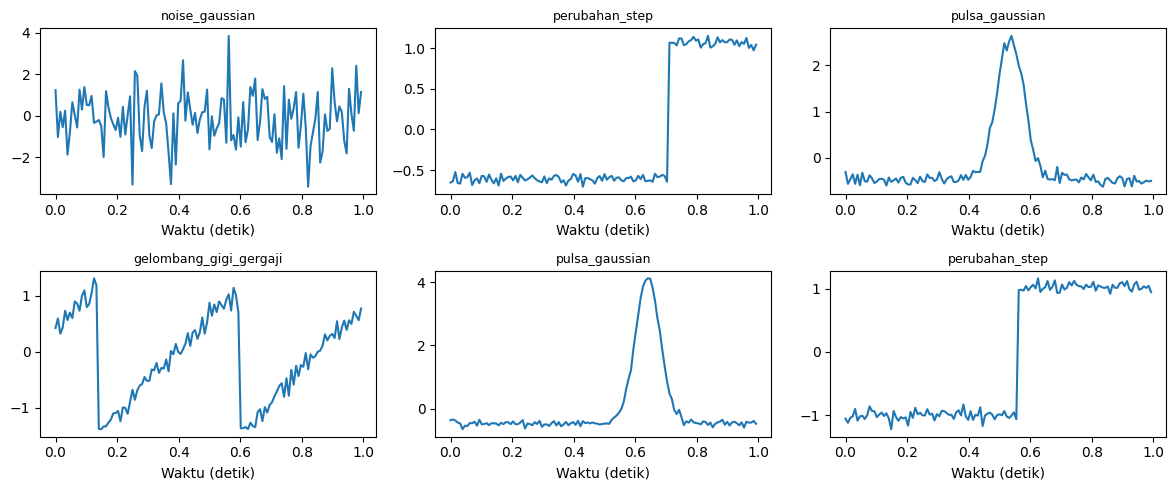

In [20]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5), squeeze=False)
for a in ax.flat:
    a.axis("off")
for i, a in enumerate(ax.flat):
    if i >= len(signals):
        break
    y = signals[i]
    a.axis("on")
    a.plot(np.arange(len(y)) / sr, y)
    title = class_names[int(y_true[i])] if y_true is not None and class_names is not None else f"Sinyal {i}"
    a.set_title(title, fontsize=9)
    a.set_xlabel("Waktu (detik)")
plt.tight_layout()
plt.show()


## Spektrum frekuensi
Menampilkan kekuatan frekuensi satu sinyal setelah mengurangi offset.

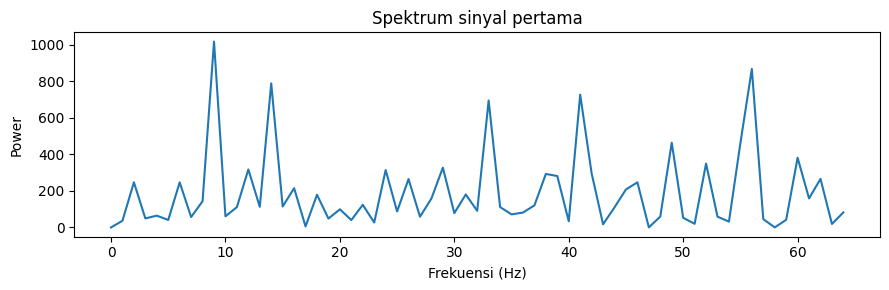

In [21]:
y = np.asarray(signals[0], dtype=np.float32)
freq = np.fft.rfftfreq(len(y), d=1 / sr)
power = np.abs(np.fft.rfft(y - y.mean())) ** 2

plt.figure(figsize=(9, 3))
plt.plot(freq, power)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power")
plt.title("Spektrum sinyal pertama")
plt.tight_layout()
plt.show()

# Untuk rekaman audio asli, aktifkan jika ingin mendengarkan:
# from IPython.display import Audio, display
# display(Audio(signals[0], rate=sr))


## Preprocessing dan ekstraksi fitur
Gunakan statistik amplitudo dan frekuensi. Semua sinyal menghasilkan 9 fitur meskipun durasinya berbeda.
Fitur ini merupakan baseline sederhana; belum tentu memisahkan seluruh jenis sinyal dengan sempurna.

In [22]:
def extract_features(y, sr):
    y = np.asarray(y, dtype=np.float32)
    if y.ndim != 1 or len(y) < 2 or not np.isfinite(y).all():
        raise ValueError("Sinyal harus mono, minimal 2 titik, dan tidak mengandung NaN/inf.")
    centered = y - y.mean()  # kurangi offset untuk fitur frekuensi
    power = np.abs(np.fft.rfft(centered)) ** 2
    freq = np.fft.rfftfreq(len(y), d=1 / sr)
    weights = power / max(power.sum(), 1e-12)
    centroid = np.sum(freq * weights)

    return [y.mean(), y.std(), np.sqrt(np.mean(y ** 2)), np.ptp(y),
            np.mean(np.diff(np.signbit(centered))),
            freq[np.argmax(power)], centroid,
            np.sqrt(np.sum((freq - centroid) ** 2 * weights)),
            np.sum(weights ** 2)]

feature_names = ["mean", "std", "rms", "range", "zcr", "dominant_hz", "centroid_hz", "bandwidth_hz", "spectral_concentration"]
X = np.array([extract_features(y, sr) for y in tqdm(signals)])
df_features = pd.DataFrame(X, columns=feature_names)
print(X.shape)
df_features.head()


  0%|          | 0/5000 [00:00<?, ?it/s]

(5000, 9)


,mean,std,rms,range,zcr,dominant_hz,centroid_hz,bandwidth_hz,spectral_concentration
0,-0.130010,1.226061,1.232934,7.277344,0.535433,9.0,32.802034,18.120400,0.035405
1,-0.122948,0.761313,0.771177,1.855957,0.007874,1.0,2.969687,6.649582,0.433164
2,-0.134026,0.792160,0.803418,3.265137,0.015748,1.0,2.701162,3.928199,0.238589
3,-0.088813,0.763036,0.768187,2.700195,0.062992,2.0,5.873007,9.500946,0.343878
4,0.006913,1.140005,1.140026,4.759277,0.015748,1.0,2.664035,2.541075,0.218929


## Scaling

In [23]:
X_scaled = StandardScaler().fit_transform(X)

# Alternatif kalau ada outlier; bandingkan hasilnya dulu:
# from sklearn.preprocessing import RobustScaler
# X_scaled = RobustScaler().fit_transform(X)


## Tentukan k

  0%|          | 0/13 [00:00<?, ?it/s]

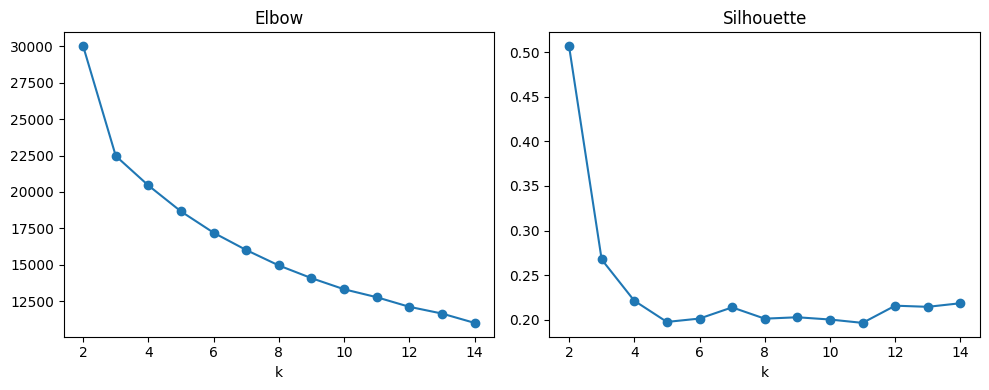

In [24]:
ks = range(2, min(15, len(X_scaled)))
inertia, sil = [], []
for k in tqdm(ks):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_, sample_size=min(3000, len(X_scaled)), random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Elbow")
ax[1].plot(ks, sil, "o-"); ax[1].set_title("Silhouette")
for a in ax:
    a.set_xlabel("k")
plt.tight_layout()
plt.show()


k dipilih = ... karena ... (isi berdasarkan grafik dan isi cluster).

## KMeans + evaluasi

In [25]:
k = 2  # GANTI sesuai grafik; jumlah kelas asli bukan penentu k terbaik
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

print("Silhouette    :", silhouette_score(X_scaled, labels, sample_size=min(3000, len(X_scaled)), random_state=42))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, labels))
print(pd.Series(labels).value_counts().sort_index())


Silhouette    : 0.5067105986300006
Davies-Bouldin: 0.8268382158103428
0    4513
1     487
Name: count, dtype: int64


## Plot cluster (PCA)
PCA hanya untuk visualisasi; KMeans memakai 9 fitur yang sudah di-scale.

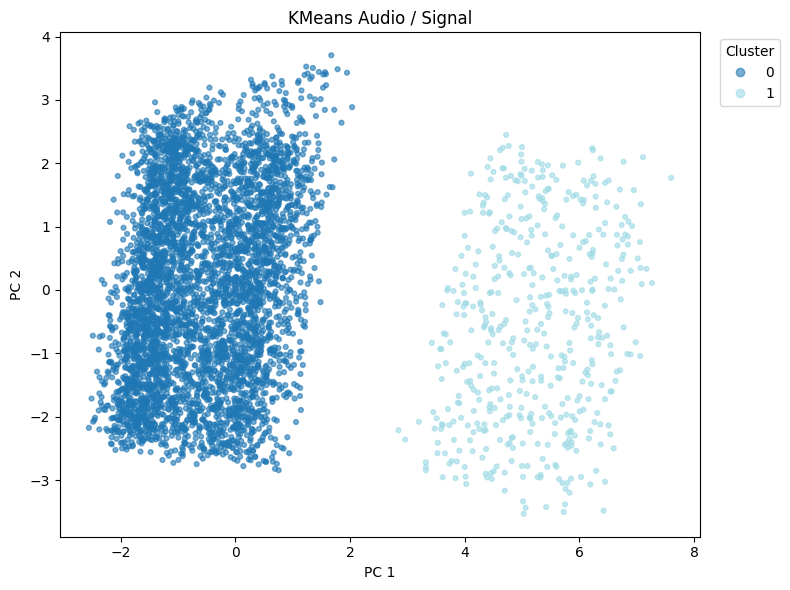

In [26]:
p2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sc = plt.scatter(p2[:, 0], p2[:, 1], c=labels, cmap="tab20", s=12, alpha=0.6)
plt.legend(*sc.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.title("KMeans Audio / Signal")
plt.tight_layout()
plt.show()


## Insight tiap cluster
Lihat jumlah anggota dan rata-rata fitur, lalu beri arti berdasarkan contoh sinyal.

In [27]:
summary = df_features.copy()
summary["cluster"] = labels
jumlah = summary.groupby("cluster").size().rename("jumlah")
profil = summary.groupby("cluster")[feature_names].mean().round(3)
profil.insert(0, "persen", (jumlah / len(labels) * 100).round(1))
profil.insert(0, "jumlah", jumlah)
display(profil)


,jumlah,persen,mean,std,rms,range,zcr,dominant_hz,centroid_hz,bandwidth_hz,spectral_concentration
cluster,,,,,,,,,,,
0,4513,90.3,0.002,1.002,1.006,3.424,0.092,5.584,7.250,5.595,0.429
1,487,9.7,0.005,1.002,1.006,5.260,0.503,33.333,32.567,18.277,0.031


## Contoh sinyal tiap cluster
Maksimal tiga contoh acak; cluster kecil tetap dapat ditampilkan.

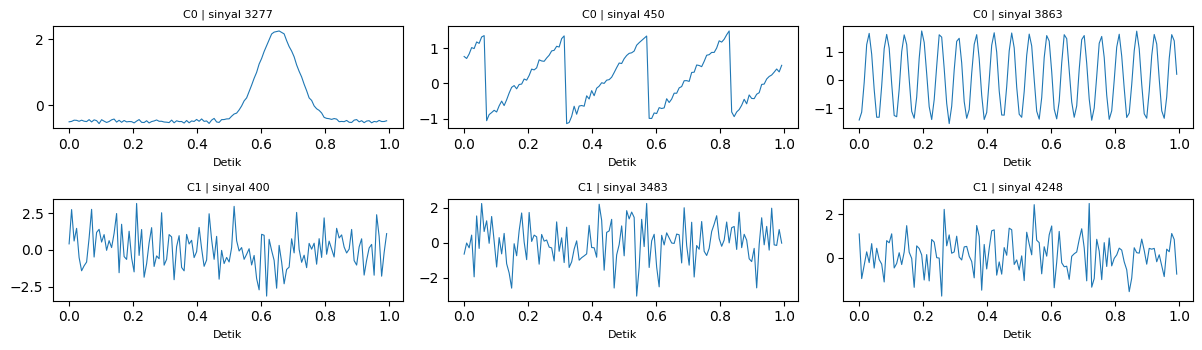

In [28]:
rng = np.random.default_rng(42)
fig, ax = plt.subplots(k, 3, figsize=(12, 1.8 * k), squeeze=False)
for a in ax.flat:
    a.axis("off")
for c in range(k):
    members = np.flatnonzero(labels == c)
    idx = rng.choice(members, size=min(3, len(members)), replace=False)
    for a, i in zip(ax[c], idx):
        y = signals[i]
        a.axis("on")
        a.plot(np.arange(len(y)) / sr, y, linewidth=0.8)
        a.set_title(f"C{c} | sinyal {i}", fontsize=8)
        a.set_xlabel("Detik", fontsize=8)
plt.tight_layout()
plt.show()


## Bandingkan dengan label asli (opsional)

In [29]:
if y_true is not None:
    comparison = pd.crosstab(labels, y_true)
    if class_names is not None:
        comparison.columns = [class_names[int(c)] for c in comparison.columns]
    display(comparison)
else:
    print("Label asli tidak tersedia; evaluasi internal tetap bisa digunakan.")


,sinus_rendah,sinus_tinggi,gelombang_kotak,gelombang_gigi_gergaji,gelombang_segitiga,chirp_naik,sinus_teredam,pulsa_gaussian,perubahan_step,noise_gaussian
row_0,,,,,,,,,,
0,480,511,494,494,478,509,501,526,520,0
1,0,0,0,0,0,0,0,0,0,487


## Kesimpulan
- k dipilih = ... karena ...
- Evaluasi: silhouette = ..., Davies-Bouldin = ...
- Cluster dominan: ...
- Perbedaan amplitudo/frekuensi antarcluster: ...
- Cluster yang masih bercampur: ...

In [30]:
# Simpan hasil jika diperlukan:
# df_features.assign(cluster=labels).to_csv("audio_hasil.csv", index=False)
# profil.to_csv("audio_profil_cluster.csv")
